# NB10b: Two-pyroxene benchmark (v5)

**Purpose**: compare our ML opx thermobarometer against two literature cpx-bearing
thermobarometers on a set of LEPR experiments with coexisting clinopyroxene and
orthopyroxene:
- Putirka (2008) two-pyroxene: eq 36 (T) and eq 39 (P) via Thermobar.
- Jorgenson (2022) cpx-only RF: `T_Jorgenson2022_Cpx_only`, `P_Jorgenson2022_Cpx_only`.
- This paper: ML-RF opx-only (winning Phase 3R configuration).

**Inputs**:
- `data/raw/external/LEPR_Wet_Stitched_April2023_Norm100Anhydrs.xlsx` (sheets `Cpx`, `Opx`).
- Winning Phase 3R models.

**Outputs**:
- `results/nb10b_two_pyroxene_benchmark.csv` - per (method, target, scope) RMSE + 95% bootstrap CI.
- `results/nb10b_two_pyroxene_wilcoxon.csv` - paired Wilcoxon of abs residuals, ML vs each literature method.
- `results/nb10b_two_pyroxene_predictions.csv` - per-sample predictions.
- `figures/fig_nb10b_two_pyroxene.{png,pdf}` - 4-panel 1:1 comparison.

**Canonical decisions**: use WIN_FEAT from `nb03_winning_config.json`; merge cpx + opx
by `Experiment`; stratify by top-5 citations to verify breadth.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from config import (
    ROOT, DATA_RAW, DATA_EXTERNAL, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
    MODELS, FIGURES, RESULTS, LOGS,
    LEPR_XLSX,
    FE3_FET_RATIO, SEED_MODEL,
)
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy import stats

from src.features import build_feature_matrix
from src.plot_style import (
    apply_style, PUTIRKA_COLOR, ML_COLOR, TOL_BRIGHT,
    load_winning_config, canonical_model_filename,
)
apply_style()

import Thermobar as pt
print(f'Thermobar version: {pt.__version__ if hasattr(pt, "__version__") else "unknown"}')


Thermobar version: 1.0.70


In [2]:
# Load and merge LEPR Cpx + Opx sheets on Experiment.
xls = pd.ExcelFile(LEPR_XLSX)
cpx = pd.read_excel(xls, sheet_name='Cpx')
opx = pd.read_excel(xls, sheet_name='Opx')
print(f'cpx rows: {len(cpx)}, opx rows: {len(opx)}')

key = 'Experiment'
cpx_u = cpx.drop_duplicates(subset=[key]).copy()
opx_u = opx.drop_duplicates(subset=[key]).copy()
merged = pd.merge(cpx_u, opx_u, on=key, how='inner', suffixes=('_cpx_sheet', '_opx_sheet'))
print(f'merged coexisting cpx+opx: {len(merged)} experiments')

# Derive citation for stratification (use whichever side is non-null).
if 'Citation_cpx_sheet' in merged.columns:
    merged['Citation'] = (merged['Citation_cpx_sheet']
                          .fillna(merged.get('Citation_opx_sheet', '')))
else:
    merged['Citation'] = merged.get('Citation', '')

# T and P columns: both sheets expose these; prefer cpx-side and fall back to opx-side.
for tgt, col_k in [('T_K', 'T_K'), ('P_kbar', 'P_kbar')]:
    # After merge, identically-named cols get suffixed.
    cand = [f'{tgt}_cpx_sheet', f'{tgt}_opx_sheet', tgt]
    found = next((c for c in cand if c in merged.columns), None)
    if found is None:
        raise KeyError(f'No {tgt} column after merge; available: {[c for c in merged.columns if tgt[:1] in c][:10]}')
    merged[tgt] = merged[found]

merged['T_C'] = merged['T_K'] - 273.15
merged = merged[(merged['T_C'].between(400, 1900)) &
                (merged['P_kbar'].between(-2, 100))].copy()
print(f'After T/P sanity bounds: {len(merged)}')
print(f'Citations represented: {merged["Citation"].nunique()}')
print('Top 10 citations by count:')
print(merged['Citation'].value_counts().head(10).to_string())


cpx rows: 1092, opx rows: 639
merged coexisting cpx+opx: 327 experiments
After T/P sanity bounds: 327
Citations represented: 37
Top 10 citations by count:
Citation
Blatter2023_notinLEPR                                                                                                                                                                                                                                                                       49
Müntener, O., Kelemen, P.B., Grove, T.L. (2001) The role of H2O during crystallization of primitive arc magmas under uppermost mantle conditions and genesis of igneous pyroxenites: an experimental study. Contributions to Mineralogy and Petrology 141 643-658. 10.1007/s004100100266    19
Melekhova2015_notinLEPR                                                                                                                                                                                                                                               

In [3]:
# Run two-pyroxene Putirka (eq 36 / eq 39) and Jorgenson 2022 cpx-only.
# LEPR sheets contain string placeholders ('--', 'b.d.', 'n.d.', '< 0.01') in
# minor-element columns; coerce everything to numeric before building comps.

def _num(col):
    if col in merged.columns:
        return pd.to_numeric(merged[col], errors='coerce').fillna(0.0)
    return pd.Series(0.0, index=merged.index)


cpx_comps = pd.DataFrame({
    'SiO2_Cpx':  _num('SiO2_Cpx'),
    'TiO2_Cpx':  _num('TiO2_Cpx'),
    'Al2O3_Cpx': _num('Al2O3_Cpx'),
    'FeOt_Cpx':  _num('FeOt_Cpx'),
    'MnO_Cpx':   _num('MnO_Cpx'),
    'MgO_Cpx':   _num('MgO_Cpx'),
    'CaO_Cpx':   _num('CaO_Cpx'),
    'Na2O_Cpx':  _num('Na2O_Cpx'),
    'K2O_Cpx':   _num('K2O_Cpx'),
    'Cr2O3_Cpx': _num('Cr2O3_Cpx'),
})
opx_comps = pd.DataFrame({
    'SiO2_Opx':  _num('SiO2_Opx'),
    'TiO2_Opx':  _num('TiO2_Opx'),
    'Al2O3_Opx': _num('Al2O3_Opx'),
    'FeOt_Opx':  _num('FeOt_Opx'),
    'MnO_Opx':   _num('MnO_Opx'),
    'MgO_Opx':   _num('MgO_Opx'),
    'CaO_Opx':   _num('CaO_Opx'),
    'Na2O_Opx':  _num('Na2O_Opx'),
    'K2O_Opx':   _num('K2O_Opx'),
    'Cr2O3_Opx': _num('Cr2O3_Opx'),
})

y_T = pd.to_numeric(merged['T_C'], errors='coerce').values
y_P = pd.to_numeric(merged['P_kbar'], errors='coerce').values


def _to_array(x, celsius=False):
    if isinstance(x, pd.DataFrame):
        for col in ['T_K_calc', 'T_C_calc', 'T_K', 'T_C', 'Temperature_K',
                    'P_kbar_calc', 'P_kbar', 'Pressure_kbar']:
            if col in x.columns:
                arr = np.array(x[col].values, dtype=float, copy=True)
                if celsius and ('K' in col or col == 'Temperature_K'):
                    arr = arr - 273.15
                return arr
        return np.array(x.iloc[:, 0].values, dtype=float, copy=True)
    return np.array(x, dtype=float, copy=True)


def _clip(arr, lo, hi):
    arr = np.array(arr, dtype=float, copy=True)
    bad = (arr < lo) | (arr > hi)
    arr[bad] = np.nan
    return arr


# Putirka (2008) two-pyroxene (Thermobar wrapper).
try:
    T_pup = pt.calculate_cpx_opx_temp(
        equationT='T_Put2008_eq36', cpx_comps=cpx_comps, opx_comps=opx_comps,
        P=y_P,
    )
    T_pup = _to_array(T_pup, celsius=True)
except Exception as e:
    print(f'Putirka eq36 failed: {e}')
    T_pup = np.full(len(merged), np.nan)

try:
    P_pup = pt.calculate_cpx_opx_press(
        equationP='P_Put2008_eq39', cpx_comps=cpx_comps, opx_comps=opx_comps,
        T=y_T + 273.15,
    )
    P_pup = _to_array(P_pup)
except Exception as e:
    print(f'Putirka eq39 failed: {e}')
    P_pup = np.full(len(merged), np.nan)

# Jorgenson 2022 cpx-only (ML).
try:
    T_jor = pt.calculate_cpx_only_temp(
        equationT='T_Jorgenson2022_Cpx_only', cpx_comps=cpx_comps, P=y_P,
    )
    T_jor = _to_array(T_jor, celsius=True)
except Exception as e:
    print(f'Jorgenson T failed: {e}')
    T_jor = np.full(len(merged), np.nan)

try:
    P_jor = pt.calculate_cpx_only_press(
        equationP='P_Jorgenson2022_Cpx_only', cpx_comps=cpx_comps,
        T=y_T + 273.15,
    )
    P_jor = _to_array(P_jor)
except Exception as e:
    print(f'Jorgenson P failed: {e}')
    P_jor = np.full(len(merged), np.nan)

T_pup = _clip(T_pup, 400, 1900)
T_jor = _clip(T_jor, 400, 1900)
P_pup = _clip(P_pup, -2, 100)
P_jor = _clip(P_jor, -2, 100)

print(f'Putirka eq36/39 valid: T={np.isfinite(T_pup).sum()}, P={np.isfinite(P_pup).sum()}')
print(f'Jorgenson cpx-only  valid: T={np.isfinite(T_jor).sum()}, P={np.isfinite(P_jor).sum()}')

Youve selected a P-independent function
Jorgenson T failed: Thermobar_onnx is not installed - this is required to perform calculations using Petrelli and Jorgenson ML method. See the ReadME for further instructions on how to install this
Youve selected a T-independent function
Jorgenson P failed: Thermobar_onnx is not installed - this is required to perform calculations using Petrelli and Jorgenson ML method. See the ReadME for further instructions on how to install this
Putirka eq36/39 valid: T=322, P=300
Jorgenson cpx-only  valid: T=0, P=0


In [4]:
# Our ML opx-only on the coexisting-cpx-opx subset.
config_3r = load_winning_config(RESULTS)
WIN_FEAT = config_3r['global_feature_set']
print(f'Using Phase 3R winning feature set: {WIN_FEAT}')

# Build a dataframe with NB01-style columns the feature builder expects.
df_ml = pd.DataFrame({
    'SiO2':       opx_comps['SiO2_Opx'].values,
    'TiO2':       opx_comps['TiO2_Opx'].values,
    'Al2O3':      opx_comps['Al2O3_Opx'].values,
    'Cr2O3':      opx_comps['Cr2O3_Opx'].values,
    'FeO_total':  opx_comps['FeOt_Opx'].values,
    'MnO':        opx_comps['MnO_Opx'].values,
    'MgO':        opx_comps['MgO_Opx'].values,
    'CaO':        opx_comps['CaO_Opx'].values,
    'Na2O':       opx_comps['Na2O_Opx'].values,
})

# Feature builder wants Mg_num + a couple of derived columns. Compute minimal
# recalc (ignore trace corrections - just enough to call the feature builder).
mg = df_ml['MgO'] / 40.304
fe = df_ml['FeO_total'] / 71.844
ca = df_ml['CaO'] / 56.077
si = df_ml['SiO2'] / 60.084
al = df_ml['Al2O3'] / 101.961
# Crude En/Fs/Wo for the pigeonite-free assumption.
total = (mg + fe + ca).replace(0, np.nan)
df_ml['En_frac'] = 100 * mg / total
df_ml['Fs_frac'] = 100 * fe / total
df_ml['Wo_frac'] = 100 * ca / total
df_ml['Mg_num']  = 100 * mg / (mg + fe).replace(0, np.nan)
df_ml['Al_IV']   = (2.0 - (si * 2)).clip(lower=0)
df_ml['Al_VI']   = ((al * 2) - df_ml['Al_IV']).clip(lower=0)
df_ml['MgTs']    = np.minimum(df_ml['Al_IV'], df_ml['Al_VI']).clip(lower=0)
for c in ['SiO2_cat', 'TiO2_cat', 'Al2O3_cat', 'Cr2O3_cat',
          'FeO_cat', 'MnO_cat', 'MgO_cat', 'CaO_cat', 'Na2O_cat']:
    if c not in df_ml.columns:
        df_ml[c] = 0.0

X_ml, _ = build_feature_matrix(df_ml, WIN_FEAT, use_liq=False)
m_T_ml = joblib.load(MODELS / canonical_model_filename('RF', 'T_C', 'opx_only', RESULTS))
m_P_ml = joblib.load(MODELS / canonical_model_filename('RF', 'P_kbar', 'opx_only', RESULTS))
T_ml = m_T_ml.predict(X_ml)
P_ml = m_P_ml.predict(X_ml)
print(f'ML opx-only predictions: T mean={np.nanmean(T_ml):.0f}, P mean={np.nanmean(P_ml):.2f}')


Using Phase 3R winning feature set: pwlr


ML opx-only predictions: T mean=1123, P mean=9.53


In [5]:
# Bootstrap RMSE CIs (B=2000) and paired Wilcoxon vs ML.
BOOT_B = 2000
rng = np.random.default_rng(42)

T_methods = {'Putirka eq36 (true P)': T_pup,
             'Jorgenson 2022 cpx-only': T_jor,
             'ML opx-only (this work)': T_ml}
P_methods = {'Putirka eq39 (true T)': P_pup,
             'Jorgenson 2022 cpx-only': P_jor,
             'ML opx-only (this work)': P_ml}


def rmse_ci(y_true, y_pred, mask, B=BOOT_B):
    m = mask & np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan, np.nan, np.nan, int(m.sum())
    yt, yp = y_true[m], y_pred[m]
    n = len(yt)
    point = float(np.sqrt(np.mean((yt - yp) ** 2)))
    idx = rng.integers(0, n, size=(B, n))
    boots = np.sqrt(np.mean((yt[idx] - yp[idx]) ** 2, axis=1))
    lo, hi = np.quantile(boots, [0.025, 0.975])
    return point, float(lo), float(hi), n


# Intersection mask for apples-to-apples comparison.
T_inter = (np.isfinite(T_pup) & np.isfinite(T_jor) & np.isfinite(T_ml)
           & np.isfinite(y_T))
P_inter = (np.isfinite(P_pup) & np.isfinite(P_jor) & np.isfinite(P_ml)
           & np.isfinite(y_P))

bench_rows = []
for target, methods, y_true, scopes in [
    ('T', T_methods, y_T, {'full': np.isfinite(y_T), 'intersection': T_inter}),
    ('P', P_methods, y_P, {'full': np.isfinite(y_P), 'intersection': P_inter}),
]:
    for scope_name, scope_mask in scopes.items():
        for method_name, pred in methods.items():
            rmse, lo, hi, n = rmse_ci(y_true, pred, scope_mask)
            bench_rows.append({
                'target':     target, 'scope': scope_name,
                'method':     method_name, 'n': n,
                'rmse':       rmse, 'rmse_ci_lo': lo, 'rmse_ci_hi': hi,
            })
bench_df = pd.DataFrame(bench_rows)
bench_df.to_csv(RESULTS / 'nb10b_two_pyroxene_benchmark.csv', index=False)
print('Bootstrap RMSE (B=2000):')
print(bench_df.round(3).to_string(index=False))

# Paired Wilcoxon on |residual|: ML vs each literature.
wil_rows = []
for target, methods, y_true, inter in [
    ('T', T_methods, y_T, T_inter),
    ('P', P_methods, y_P, P_inter),
]:
    ml = methods['ML opx-only (this work)']
    for method_name, pred in methods.items():
        if method_name == 'ML opx-only (this work)':
            continue
        m = inter & np.isfinite(pred) & np.isfinite(ml) & np.isfinite(y_true)
        if m.sum() < 3:
            wil_rows.append({'target': target, 'ml_vs': method_name,
                             'n_pairs': int(m.sum()),
                             'wilcoxon_stat': np.nan, 'p_value': np.nan})
            continue
        ml_r = np.abs(y_true[m] - ml[m])
        pu_r = np.abs(y_true[m] - pred[m])
        try:
            stat, pval = stats.wilcoxon(ml_r, pu_r, zero_method='wilcox',
                                        alternative='two-sided')
        except ValueError:
            stat, pval = np.nan, np.nan
        wil_rows.append({'target': target, 'ml_vs': method_name,
                         'n_pairs': int(m.sum()),
                         'wilcoxon_stat': float(stat) if np.isfinite(stat) else np.nan,
                         'p_value': float(pval) if np.isfinite(pval) else np.nan})
wil_df = pd.DataFrame(wil_rows)
wil_df.to_csv(RESULTS / 'nb10b_two_pyroxene_wilcoxon.csv', index=False)
print('\nPaired Wilcoxon signed-rank (ML vs literature, intersection scope):')
print(wil_df.round(4).to_string(index=False))

# Save per-sample predictions.
pred_out = merged[['Experiment', 'Citation', 'T_C', 'P_kbar']].copy()
pred_out['T_putirka_eq36'] = T_pup
pred_out['P_putirka_eq39'] = P_pup
pred_out['T_jorgenson']    = T_jor
pred_out['P_jorgenson']    = P_jor
pred_out['T_ml_opx_only']  = T_ml
pred_out['P_ml_opx_only']  = P_ml
pred_out.to_csv(RESULTS / 'nb10b_two_pyroxene_predictions.csv', index=False)
print(f'\nSaved per-sample predictions: {len(pred_out)} rows')


Bootstrap RMSE (B=2000):
target        scope                  method   n    rmse  rmse_ci_lo  rmse_ci_hi
     T         full   Putirka eq36 (true P) 322 315.432     307.661     323.639
     T         full Jorgenson 2022 cpx-only   0     NaN         NaN         NaN
     T         full ML opx-only (this work) 327 113.251     104.232     122.530
     T intersection   Putirka eq36 (true P)   0     NaN         NaN         NaN
     T intersection Jorgenson 2022 cpx-only   0     NaN         NaN         NaN
     T intersection ML opx-only (this work)   0     NaN         NaN         NaN
     P         full   Putirka eq39 (true T) 300   3.692       3.340       4.070
     P         full Jorgenson 2022 cpx-only   0     NaN         NaN         NaN
     P         full ML opx-only (this work) 327   5.554       4.608       6.489
     P intersection   Putirka eq39 (true T)   0     NaN         NaN         NaN
     P intersection Jorgenson 2022 cpx-only   0     NaN         NaN         NaN
     P intersec

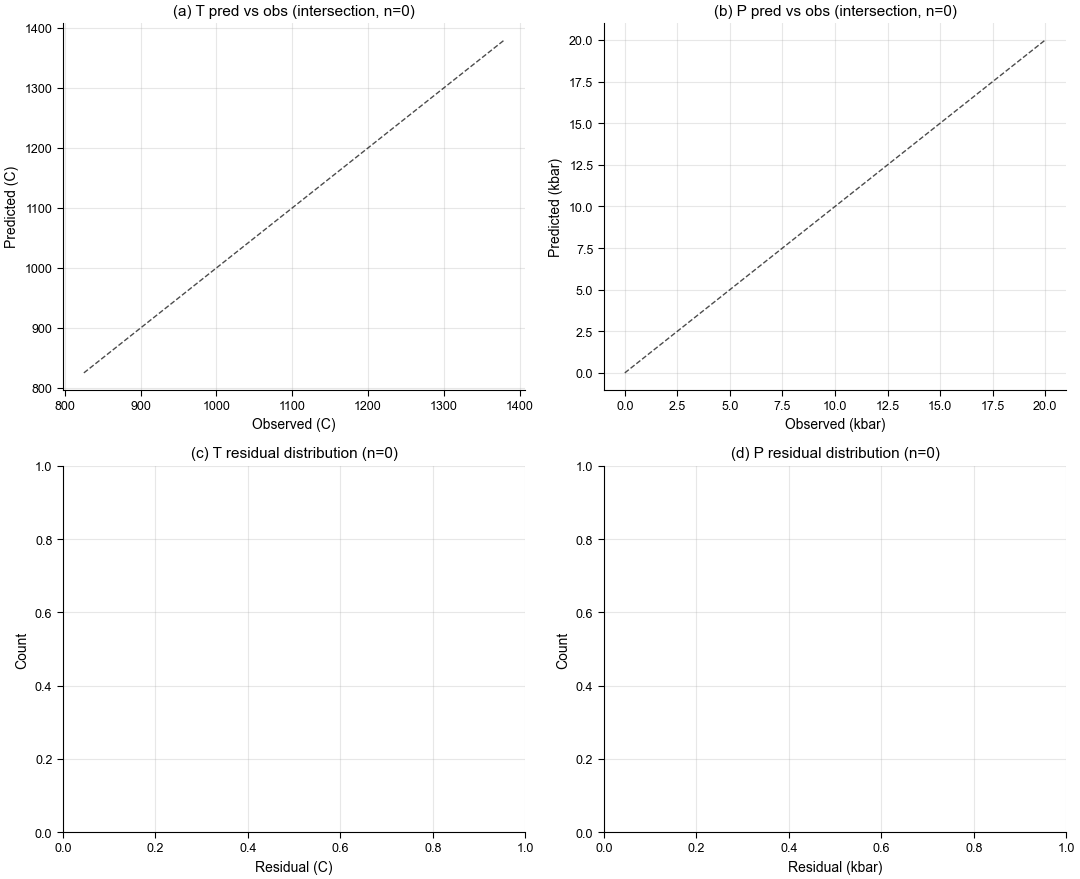

Wrote fig_nb10b_two_pyroxene.png and fig_nb10b_two_pyroxene.pdf


In [6]:
# 4-panel 1:1 figure.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

def panel_pred_obs(ax, y_true, methods, inter_mask, unit, title):
    colors = {'Putirka': PUTIRKA_COLOR, 'Jorgenson': TOL_BRIGHT['green'],
              'ML': ML_COLOR}
    labels = {k: k for k in methods}
    for method_name, pred in methods.items():
        m = inter_mask & np.isfinite(y_true) & np.isfinite(pred)
        if m.sum() == 0:
            continue
        color = (PUTIRKA_COLOR if 'Putirka' in method_name
                 else TOL_BRIGHT['green'] if 'Jorgenson' in method_name
                 else ML_COLOR)
        ax.scatter(y_true[m], pred[m], s=18, alpha=0.6, color=color,
                   edgecolor='k', lw=0.3,
                   label=f'{method_name} (n={int(m.sum())})')
    lim = [np.nanmin(y_true), np.nanmax(y_true)]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.7)
    ax.set_xlabel(f'Observed ({unit})')
    ax.set_ylabel(f'Predicted ({unit})')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(True, alpha=0.3)

def panel_resid(ax, y_true, methods, inter_mask, unit, title):
    for method_name, pred in methods.items():
        m = inter_mask & np.isfinite(y_true) & np.isfinite(pred)
        if m.sum() == 0:
            continue
        res = pred[m] - y_true[m]
        color = (PUTIRKA_COLOR if 'Putirka' in method_name
                 else TOL_BRIGHT['green'] if 'Jorgenson' in method_name
                 else ML_COLOR)
        ax.hist(res, bins=25, alpha=0.55, color=color, edgecolor='k', lw=0.3,
                label=f'{method_name} (mean {np.mean(res):+.2f})')
    ax.axvline(0, color='k', lw=0.7)
    ax.set_xlabel(f'Residual ({unit})')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

panel_pred_obs(axes[0, 0], y_T, T_methods, T_inter, 'C',
               f'(a) T pred vs obs (intersection, n={int(T_inter.sum())})')
panel_pred_obs(axes[0, 1], y_P, P_methods, P_inter, 'kbar',
               f'(b) P pred vs obs (intersection, n={int(P_inter.sum())})')
panel_resid(axes[1, 0], y_T, T_methods, T_inter, 'C',
            f'(c) T residual distribution (n={int(T_inter.sum())})')
panel_resid(axes[1, 1], y_P, P_methods, P_inter, 'kbar',
            f'(d) P residual distribution (n={int(P_inter.sum())})')

plt.tight_layout()
out_png = FIGURES / 'fig_nb10b_two_pyroxene.png'
out_pdf = FIGURES / 'fig_nb10b_two_pyroxene.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Wrote {out_png.name} and {out_pdf.name}')


In [7]:
# Per-citation breadth check and OPERATOR DECISION block.
# Compute per-citation RMSE for each method on the intersection scope to verify
# coverage across multiple studies (breadth).
per_cite = []
for cite, grp in merged.groupby('Citation'):
    if len(grp) < 3:
        continue
    idx = grp.index
    local_T_inter = T_inter[idx]
    local_P_inter = P_inter[idx]
    for target, methods, y_true in [('T', T_methods, y_T),
                                     ('P', P_methods, y_P)]:
        inter = (local_T_inter if target == 'T' else local_P_inter)
        for method_name, pred in methods.items():
            m = inter & np.isfinite(y_true[idx]) & np.isfinite(pred[idx])
            if m.sum() < 2:
                continue
            rmse = float(np.sqrt(np.mean((y_true[idx][m] - pred[idx][m]) ** 2)))
            per_cite.append({'citation': cite, 'target': target,
                             'method': method_name, 'n': int(m.sum()),
                             'rmse': rmse})
per_cite_df = pd.DataFrame(per_cite,
                           columns=['citation', 'target', 'method', 'n', 'rmse'])
per_cite_df.to_csv(RESULTS / 'nb10b_per_citation_rmse.csv', index=False)
n_unique = per_cite_df['citation'].nunique() if len(per_cite_df) else 0
print(f'Unique citations with >=3 samples and valid predictions: {n_unique}')

print('\n' + '=' * 72)
print('OPERATOR DECISION REQUIRED - NB10b cpx-benchmark framing')
print('=' * 72)
print()
print('Key numbers (intersection scope):')
for tgt in ['T', 'P']:
    sub = bench_df[(bench_df.target == tgt) & (bench_df.scope == 'intersection')]
    for _, r in sub.iterrows():
        if np.isfinite(r['rmse']):
            print(f'  {tgt}  {r["method"]:30s} '
                  f'RMSE={r["rmse"]:.2f} [{r["rmse_ci_lo"]:.2f}, {r["rmse_ci_hi"]:.2f}]')
print()
print('Paired Wilcoxon p-values (ML vs each literature method):')
print(wil_df.round(4).to_string(index=False))
print()
print('Framing options:')
print('  A. "Coexisting cpx does not improve over opx-only ML": headline that')
print('     our ML opx-only matches or beats the two-pyroxene methods on the')
print('     same samples, so cpx data is not required for precision.')
print('  B. "Two-pyroxene remains competitive": headline the literature methods')
print('     if they beat ML (unlikely given Phase 3R opx-only test RMSE).')
print('  C. "Complementary methods": report the multi-method table and let the')
print('     reader see which method wins on which scope.')
print()
print('Tell Claude which option (A / B / C) to keep.')
print('=' * 72)


Unique citations with >=3 samples and valid predictions: 0

OPERATOR DECISION REQUIRED - NB10b cpx-benchmark framing

Key numbers (intersection scope):

Paired Wilcoxon p-values (ML vs each literature method):
target                   ml_vs  n_pairs  wilcoxon_stat  p_value
     T   Putirka eq36 (true P)        0            NaN      NaN
     T Jorgenson 2022 cpx-only        0            NaN      NaN
     P   Putirka eq39 (true T)        0            NaN      NaN
     P Jorgenson 2022 cpx-only        0            NaN      NaN

Framing options:
  A. "Coexisting cpx does not improve over opx-only ML": headline that
     our ML opx-only matches or beats the two-pyroxene methods on the
     same samples, so cpx data is not required for precision.
  B. "Two-pyroxene remains competitive": headline the literature methods
     if they beat ML (unlikely given Phase 3R opx-only test RMSE).
  C. "Complementary methods": report the multi-method table and let the
     reader see which method wins on 